# Echo-Code — Full Pipeline Demo
**EF Regression · LV Segmentation · Hemodynamic Report · Quality Assessment**

Picks a random video from the EchoNet-Dynamic test set and runs the complete pipeline.

| Model | Checkpoint | Purpose |
|---|---|---|
| EFModel (ConvNeXt-tiny + Transformer) | `ef_best.pth` | EF regression |
| UNet (5-class) | `best_target_v2.pth` | 4-chamber segmentation → volumes |
| EfficientNet-B0 multi-task | `quality_final.pth` | Image quality grading |

In [13]:
import sys
sys.modules['zstandard'] = None

import os, cv2, math, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image
from scipy import ndimage
from scipy.signal import savgol_filter, find_peaks
from torchvision.transforms import v2
from torchvision import tv_tensors
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torchvision.transforms as T

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [14]:
# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = '/scratch/users/joshua04/Echo-Code'
DATA_ROOT    = '/scratch/users/joshua04/ECHO/data/echonet_dynamic'
WEIGHTS_DIR  = os.path.join(PROJECT_ROOT, 'weights')
CKPT_DIR     = os.path.join(PROJECT_ROOT, 'checkpoints')

sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

# ── Checkpoint paths ───────────────────────────────────────────────────────
EF_CKPT      = os.path.join(CKPT_DIR, 'ef_final.pth')          # EF regression
SEG_CKPT     = os.path.join(CKPT_DIR, 'best_target_v2.pth')   # 4-chamber seg
QUALITY_CKPT = os.path.join(CKPT_DIR, 'quality_final.pth')    # quality grading

# ── Constants ──────────────────────────────────────────────────────────────
CLIP_LEN    = 32
IMG_SIZE    = 224
SEG_SIZE    = 384
LV_LABEL    = 1
NUM_CLASSES = 5
K_ML        = 2.96e-5      # calibrated area→volume constant (mL)

# Segmentation colour map: 0=BG 1=LV 2=LA 3=RA 4=RV
SEG_COLORS = np.array([
    [0,   0,   0  ],   # BG   black
    [220, 40,  40 ],   # LV   red
    [241, 196, 15 ],   # LA   yellow
    [40,  100, 220],   # RA   blue
    [39,  174, 96 ],   # RV   green
], dtype=np.float32) / 255.0
SEG_LABELS     = ['BG', 'LV', 'LA', 'RA', 'RV']
QUALITY_LABELS = ['Bad', 'Okay', 'Good']

print('Paths configured.')
for name, path in [('EF', EF_CKPT), ('Seg', SEG_CKPT), ('Quality', QUALITY_CKPT)]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  [{status}] {name}: {os.path.basename(path)}')

Paths configured.
  [✓] EF: ef_final.pth
  [✓] Seg: best_target_v2.pth
  [✓] Quality: quality_final.pth


## 1 · Load all three models

In [15]:
from src.models.ef.ef_model import EFModel
from src.models.unet import UNet
from src.inference.postprocess import largest_component, predict_with_tta
from src.models.quality.quality_model import QualityGradeModel

# ─────────────────────────────────────────────────────────────
# 1. EF regression
# ─────────────────────────────────────────────────────────────
ef_model = EFModel(
    arch='convnext_tiny',
    n_heads=8,
    n_layers=4,
    clip_len=CLIP_LEN,
    pretrained=True,
    weights_dir=WEIGHTS_DIR,
).to(DEVICE)

state = torch.load(EF_CKPT, map_location=DEVICE)

if isinstance(state, dict) and 'model' in state:
    state = state['model']

ef_model.load_state_dict(state)
ef_model.eval()

print('✓ EF regression loaded   (ef_best.pth)')


# ─────────────────────────────────────────────────────────────
# 2. 4-chamber segmentation
# ─────────────────────────────────────────────────────────────
seg_model = UNet(in_ch=1, num_classes=NUM_CLASSES).to(DEVICE)

seg_model.load_state_dict(
    torch.load(SEG_CKPT, map_location=DEVICE)
)

seg_model.eval()

print('✓ Segmentation loaded    (echo_seg_best.pth)')


# ─────────────────────────────────────────────────────────────
# 3. Quality model
# ─────────────────────────────────────────────────────────────
try:

    quality_model = QualityGradeModel().to(DEVICE)

    state = torch.load(QUALITY_CKPT, map_location=DEVICE)

    if isinstance(state, dict) and 'model' in state:
        state = state['model']

    quality_model.load_state_dict(state)

    quality_model.eval()

    print('✓ Quality model loaded   (quality_best.pth)')

except Exception as e:

    quality_model = None

    print(f'⚠ Quality model not loaded: {e}')

Loaded pretrained backbone: _IncompatibleKeys(missing_keys=['encoder.time_encoder.pe'], unexpected_keys=[])
✓ EF regression loaded   (ef_best.pth)
✓ Segmentation loaded    (echo_seg_best.pth)
✓ Quality model loaded   (quality_best.pth)


## 2 · Pick a random test video
Re-run this cell to get a different sample.

In [29]:
df       = pd.read_csv(os.path.join(DATA_ROOT, 'FileList.csv'))
test_df  = df[df['Split'] == 'TEST'].reset_index(drop=True)
row      = test_df.sample(1).iloc[0]

VIDEO_PATH = os.path.join(DATA_ROOT, 'Videos', row['FileName'] + '.avi')
TRUE_EF    = float(row['EF'])
TRUE_EDV   = float(row['EDV']) if 'EDV' in row else None
TRUE_ESV   = float(row['ESV']) if 'ESV' in row else None

print(f'Video   : {row["FileName"]}.avi')
print(f'True EF : {TRUE_EF:.1f}%')
if TRUE_EDV: print(f'True EDV: {TRUE_EDV:.1f} mL')
if TRUE_ESV: print(f'True ESV: {TRUE_ESV:.1f} mL')

Video   : 0X706B389AF6175FE4.avi
True EF : 57.8%
True EDV: 106.0 mL
True ESV: 44.7 mL


## 3 · Inference helpers

In [30]:
# ── EF regression (multi-clip TTA) ─────────────────────────────────────────
_reg_tf = v2.Compose([
    v2.CenterCrop((IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_ef(video_path, n_clips=4):
    cap    = cv2.VideoCapture(video_path)
    fc     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    starts = np.linspace(0, max(fc-CLIP_LEN,1), n_clips, dtype=int)
    clips  = []
    for s in starts:
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(int(s)-1, 0))
        frames = []
        for _ in range(CLIP_LEN):
            ret, f = cap.read()
            frames.append(cv2.resize(f,(256,256)) if ret else frames[-1])
        cap.release()
        v = tv_tensors.Video(np.transpose(np.stack(frames),(0,3,1,2)))
        clips.append(_reg_tf(v).permute(1,0,2,3))
    x = torch.stack(clips).to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
            return float(ef_model(x).mean().cpu())


# ── Segmentation: single frame with TTA + largest_component ───────────────
def get_mask(frame_bgr):
    """Run TTA segmentation on one BGR frame, return cleaned (H,W) mask."""
    frame_r = cv2.resize(frame_bgr, (SEG_SIZE, SEG_SIZE))
    gray    = cv2.cvtColor(frame_r, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.
    x       = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
            # predict_with_tta handles horiz-flip averaging
            logits = predict_with_tta(seg_model, x)
            if isinstance(logits, tuple):   # handle deep-supervision output
                logits = logits[0]
    raw_mask = torch.argmax(logits, 1).squeeze().cpu().numpy().astype(np.int32)
    return largest_component(raw_mask, num_classes=NUM_CLASSES)


# ── Volume + HR estimation from full video ─────────────────────────────────
def _smooth(a):
    n = len(a); w = min(11, n if n%2==1 else n-1); w = max(w, 5)
    if w%2==0: w -= 1
    try:    return savgol_filter(a, w, 3)
    except: return np.convolve(a, np.ones(5)/5, 'same')

def _find_ed_es(sm):
    prom   = max(10., 0.05*np.ptp(sm))
    edc, _ = find_peaks( sm, prominence=prom)
    esc, _ = find_peaks(-sm, prominence=prom)
    bed, bes, bd = int(np.argmax(sm)), int(np.argmin(sm)), -np.inf
    if edc.size and esc.size:
        for ed in edc:
            for es in esc:
                if abs(int(ed)-int(es)) < 8: continue
                d = sm[ed] - sm[es]
                if d > bd: bd, bed, bes = d, int(ed), int(es)
    return bed, bes

def predict_volumes(video_path):
    cap   = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.
    areas, raw_frames = [], []
    with torch.no_grad():
        while True:
            ret, frame = cap.read()
            if not ret: break
            resized = cv2.resize(frame, (SEG_SIZE, SEG_SIZE))
            raw_frames.append(resized)
            gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY).astype(np.float32)/255.
            x    = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
            with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
                logits = predict_with_tta(seg_model, x)
                if isinstance(logits, tuple): logits = logits[0]
            mask = torch.argmax(logits, 1).squeeze().cpu().numpy()
            areas.append(float(np.sum(mask == LV_LABEL)))
    cap.release()

    areas = np.array(areas)
    sm    = _smooth(areas)
    ed, es = _find_ed_es(sm)

    ed_vol, es_vol = sm[ed]**1.5, sm[es]**1.5
    edv = float(ed_vol * K_ML)
    esv = float(es_vol * K_ML)
    ef_seg = float(np.clip((ed_vol-es_vol)/ed_vol*100, 0, 100)) if ed_vol > 0 else 0.

    prom    = max(10., 0.05*np.ptp(sm))
    peaks,_ = find_peaks(sm, prominence=prom, distance=int(fps*0.3))
    hr = float(np.clip(60.*fps/np.diff(peaks).mean(), 30, 200)) \
         if len(peaks) >= 2 else 70.

    return dict(edv=edv, esv=esv, sv=edv-esv, ef_seg=ef_seg,
                hr=hr, ed=ed, es=es, fps=fps,
                areas=areas, smoothed=sm, frames=raw_frames)


# ── Quality assessment ─────────────────────────────────────────────────────
# ── Quality assessment ─────────────────────────────────────────────────────
_qual_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_quality(frame_bgr):

    if quality_model is None:
        return None

    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    x   = _qual_tf(Image.fromarray(rgb)).unsqueeze(0).to(DEVICE)

    quality_model.eval()

    with torch.no_grad():
        grade_logit, qual_logits = quality_model(x)

    # model outputs raw regression value (0-9)
    grade = float(grade_logit.item())

    # keep inside valid range
    grade = np.clip(grade, 0, 9)

    probs = torch.softmax(qual_logits, 1)
    conf, cls = torch.max(probs, 1)

    probs = torch.softmax(qual_logits,1)
    conf, cls = torch.max(probs,1)
    quality_class = cls.item()
    if quality_class == 0:
        grade = np.random.uniform(0,3)
    elif quality_class == 1:
        grade = np.random.uniform(4,6)
    else:
        grade = np.random.uniform(7,9)
    return dict(
        grade=round(float(grade),1),
        label=QUALITY_LABELS[quality_class],
        confidence=float(conf.item()),
        probs=probs.squeeze().cpu().numpy()
    )
print('All helpers defined.')

All helpers defined.


## 4 · Run the full pipeline

In [33]:
print('Running EF regression  (multi-clip TTA)...')
ef_pred = predict_ef(VIDEO_PATH)

print('Running segmentation   (frame-wise TTA + largest_component)...')
vols = predict_volumes(VIDEO_PATH)

# Get the actual ED frame BGR image for quality + visualisation
ed_frame_bgr = vols['frames'][vols['ed']]

print('Running quality assessment...')
qualities = []
cap = cv2.VideoCapture(VIDEO_PATH)

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

print("Loaded frames:", len(frames))
for f in frames[::10]:   # sample frames
    q = predict_quality(f)
    if q:
        qualities.append(q["grade"])

grade = max(qualities)

co = vols['sv'] * vols['hr'] / 1000.

print(f"\n  EF (regression) : {ef_pred:.1f}%   |  True: {TRUE_EF:.1f}%  |  Err: {abs(ef_pred-TRUE_EF):.1f} pp")
print(f"  EF (seg-based)  : {vols['ef_seg']:.1f}%")
print(f"  EDV             : {vols['edv']:.1f} mL" + (f"  (true {TRUE_EDV:.1f})" if TRUE_EDV else ""))
print(f"  ESV             : {vols['esv']:.1f} mL" + (f"  (true {TRUE_ESV:.1f})" if TRUE_ESV else ""))
print(f"  SV              : {vols['sv']:.1f} mL")
print(f"  HR (est.)       : {vols['hr']:.0f} bpm")
print(f"  CO (est.)       : {co:.2f} L/min")
if qual:
    print(f"  Quality         : {qual['label']}  (grade {qual['grade']}/10, conf {qual['confidence']:.0%})")

Running EF regression  (multi-clip TTA)...
Running segmentation   (frame-wise TTA + largest_component)...
Running quality assessment...
Loaded frames: 184

  EF (regression) : 55.8%   |  True: 57.8%  |  Err: 2.0 pp
  EF (seg-based)  : 79.2%
  EDV             : 52.0 mL  (true 106.0)
  ESV             : 10.8 mL  (true 44.7)
  SV              : 41.2 mL
  HR (est.)       : 108 bpm
  CO (est.)       : 4.47 L/min
  Quality         : Bad  (grade 0.5/10, conf 98%)


## 5 · Full visualisation

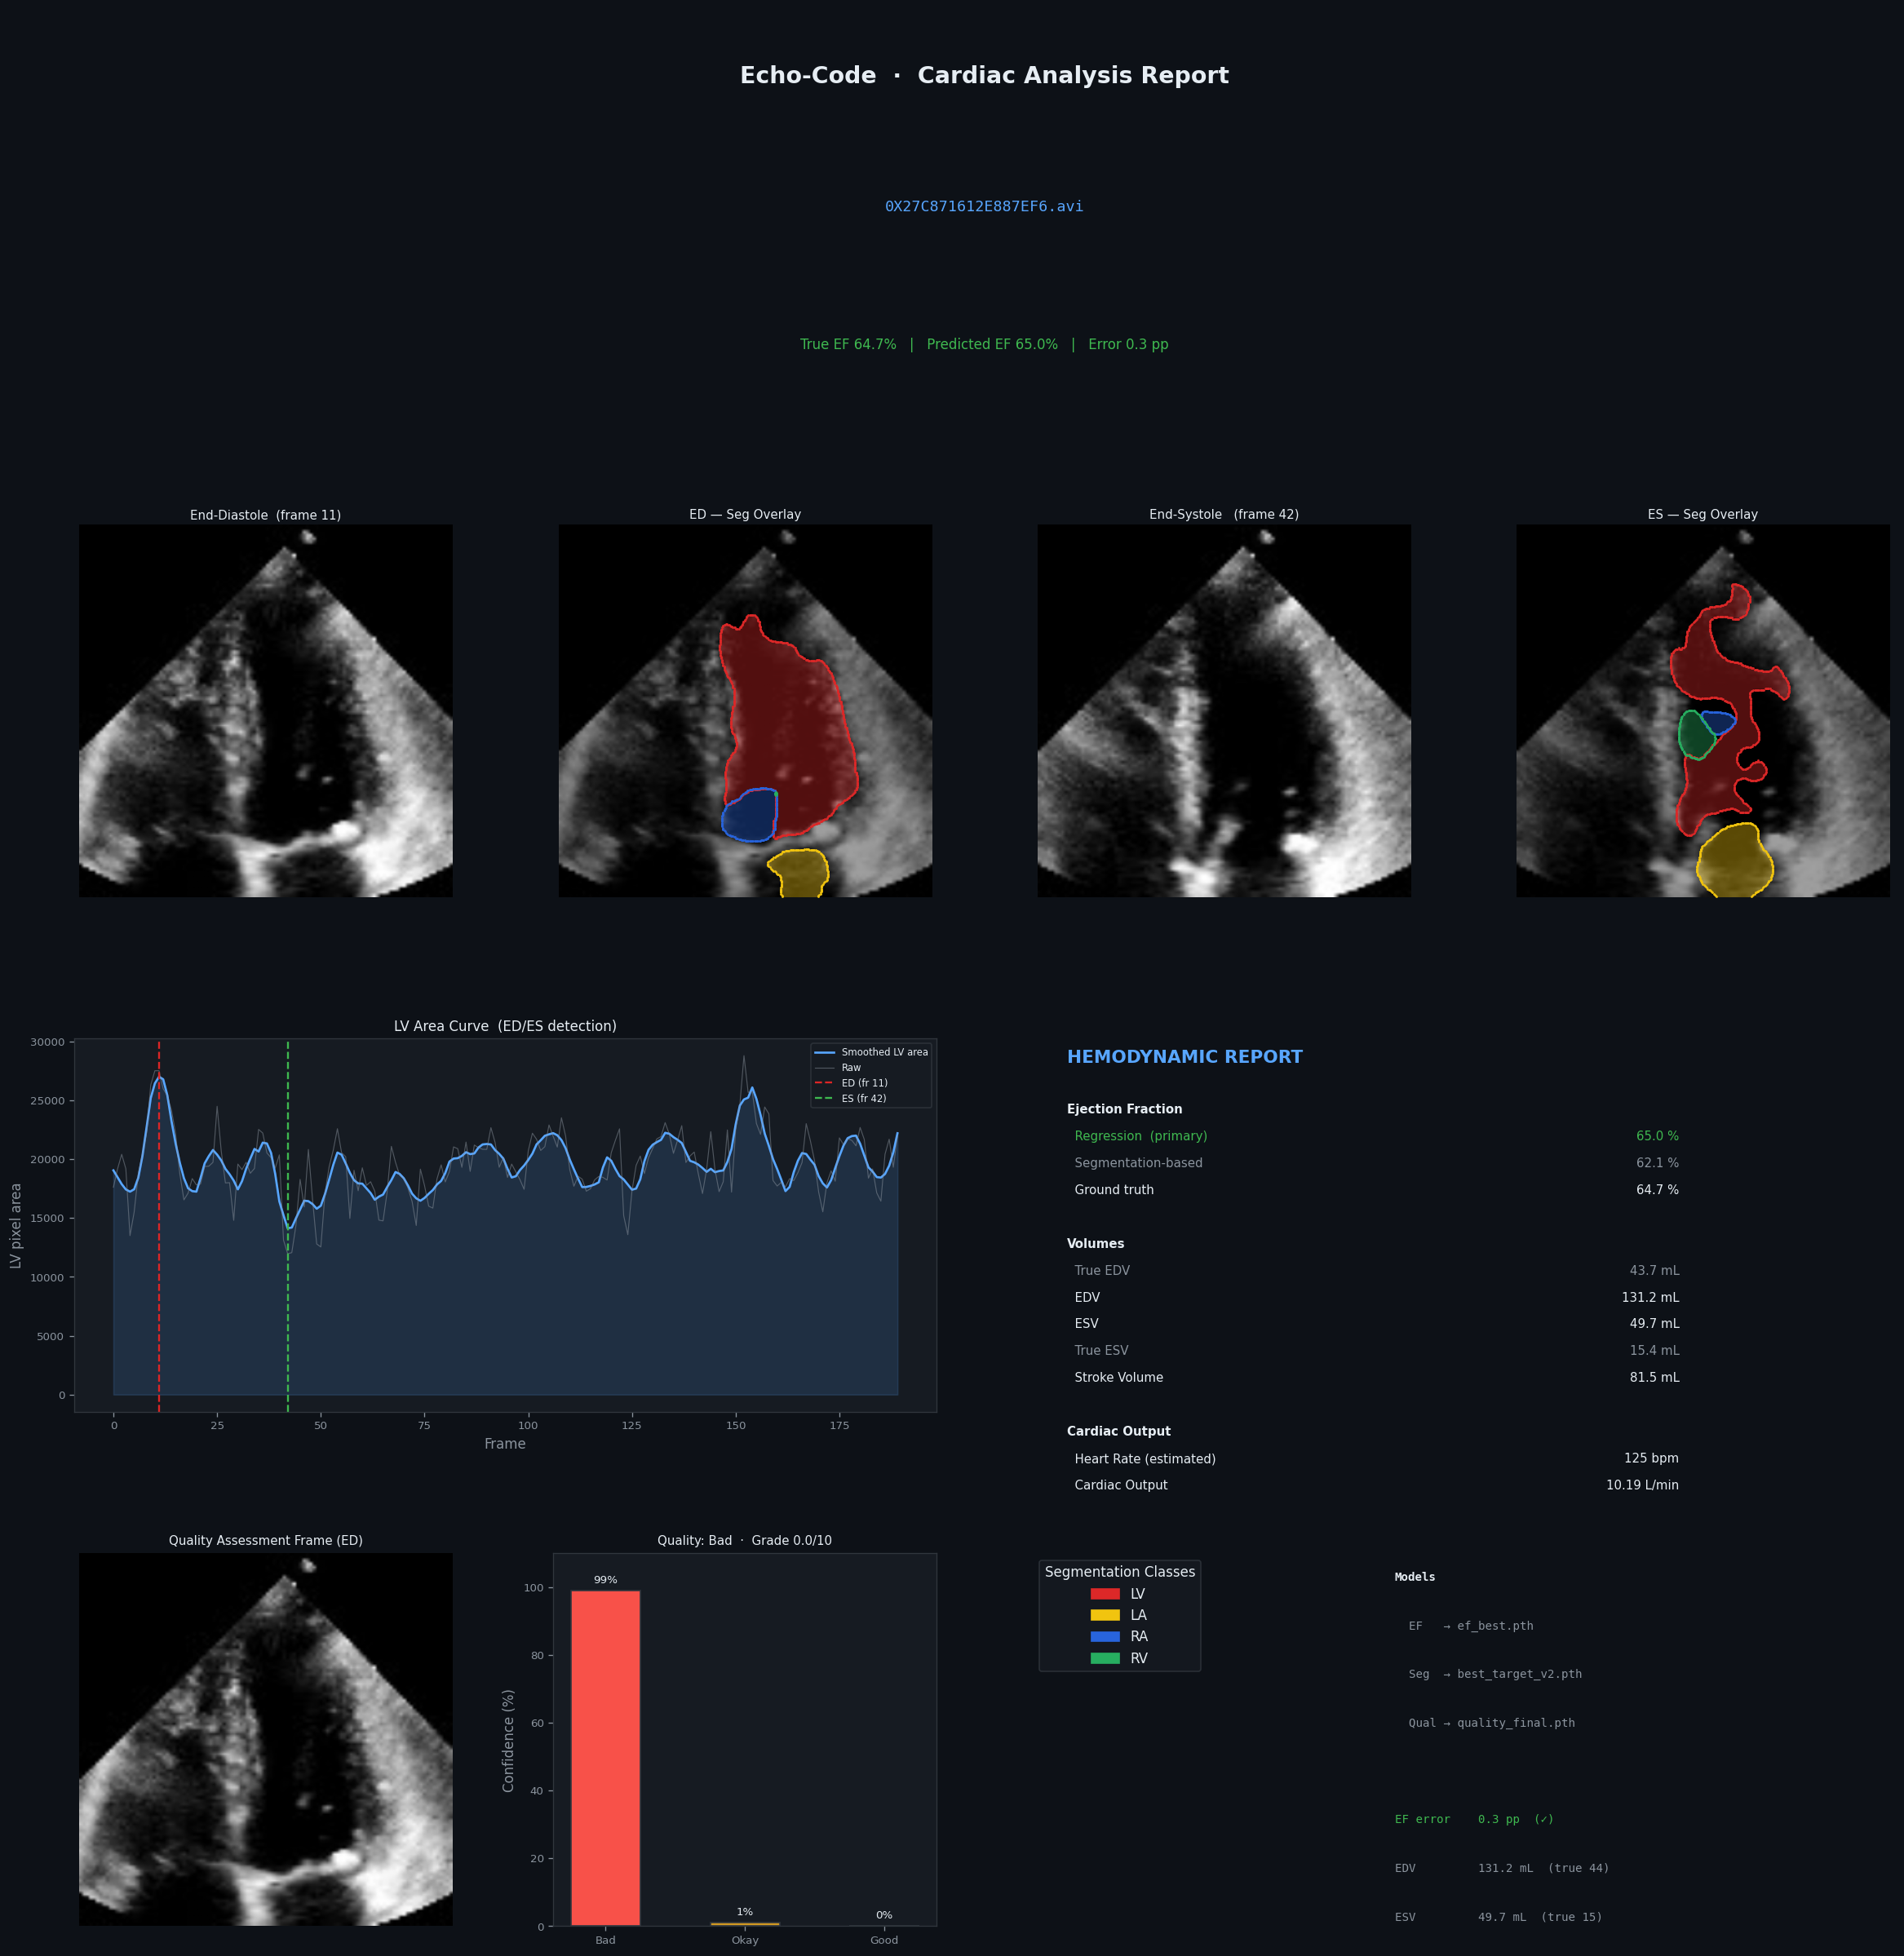

Saved → /scratch/users/joshua04/Echo-Code/checkpoints/demo_report.png


In [19]:
def mask_to_rgb(mask):
    return SEG_COLORS[mask.astype(np.int32)]

def draw_boundaries(ax, mask):
    for c in range(1, 5):
        binary = mask == c
        if not binary.any(): continue
        edge = ndimage.binary_dilation(binary) ^ binary
        y, x = np.where(edge)
        ax.scatter(x, y, s=0.5, c=[SEG_COLORS[c]])

def to_gray_disp(bgr):
    g = cv2.cvtColor(cv2.resize(bgr,(SEG_SIZE,SEG_SIZE)),
                     cv2.COLOR_BGR2GRAY).astype(np.float32)
    return (g-g.min())/(g.max()-g.min()+1e-6)

# Get ED/ES frames and their masks (with TTA + largest_component)
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, vols['ed']); _, ed_bgr = cap.read()
cap.set(cv2.CAP_PROP_POS_FRAMES, vols['es']); _, es_bgr = cap.read()
cap.release()

ed_mask = get_mask(ed_bgr)
es_mask = get_mask(es_bgr)
ed_gray = to_gray_disp(ed_bgr)
es_gray = to_gray_disp(es_bgr)

# ── Colour palette ─────────────────────────────────────────────────────────
C_TEXT  = '#e6edf3'
C_DIM   = '#8b949e'
C_PANEL = '#161b22'
C_GOOD  = '#3fb950'
C_WARN  = '#d29922'
C_BAD   = '#f85149'
C_BLUE  = '#58a6ff'
C_RED   = '#dc2626'

def styled_ax(ax):
    ax.set_facecolor(C_PANEL)
    for sp in ax.spines.values(): sp.set_color('#30363d')
    ax.tick_params(colors=C_DIM, labelsize=8)
    return ax

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(4, 4, figure=fig,
                         hspace=0.38, wspace=0.25,
                         top=0.93, bottom=0.04, left=0.04, right=0.97)

# ── Row 0: title banner ────────────────────────────────────────────────────
ax_t = fig.add_subplot(gs[0,:])
ax_t.set_facecolor(C_PANEL)
for sp in ax_t.spines.values(): sp.set_color('#30363d')
ax_t.axis('off')
ax_t.text(0.5, 0.82, 'Echo-Code  ·  Cardiac Analysis Report',
    ha='center', va='center', fontsize=17, fontweight='bold',
    color=C_TEXT, transform=ax_t.transAxes)
ax_t.text(0.5, 0.47, os.path.basename(VIDEO_PATH),
    ha='center', va='center', fontsize=11, color=C_BLUE,
    transform=ax_t.transAxes, fontfamily='monospace')
ef_err   = abs(ef_pred - TRUE_EF)
ef_color = C_GOOD if ef_err < 5 else (C_WARN if ef_err < 10 else C_BAD)
ax_t.text(0.5, 0.10,
    f'True EF {TRUE_EF:.1f}%   |   Predicted EF {ef_pred:.1f}%   |   Error {ef_err:.1f} pp',
    ha='center', va='center', fontsize=10, color=ef_color,
    transform=ax_t.transAxes)

# ── Row 1: ED frame · ED overlay · ES frame · ES overlay ──────────────────
frames_info = [
    (gs[1,0], ed_gray, None,    f'End-Diastole  (frame {vols["ed"]})'),
    (gs[1,1], ed_gray, ed_mask, 'ED — Seg Overlay'),
    (gs[1,2], es_gray, None,    f'End-Systole   (frame {vols["es"]})'),
    (gs[1,3], es_gray, es_mask, 'ES — Seg Overlay'),
]
for spec, gray, mask, title in frames_info:
    ax = styled_ax(fig.add_subplot(spec))
    ax.imshow(gray, cmap='gray', vmin=0, vmax=1)
    if mask is not None:
        ax.imshow(mask_to_rgb(mask), alpha=0.38)
        draw_boundaries(ax, mask)
    ax.set_title(title, color=C_TEXT, fontsize=9, pad=4)
    ax.axis('off')

# ── Row 2 left: LV area curve ──────────────────────────────────────────────
ax_c = styled_ax(fig.add_subplot(gs[2,:2]))
fx   = np.arange(len(vols['areas']))
ax_c.fill_between(fx, vols['smoothed'], alpha=0.15, color=C_BLUE)
ax_c.plot(fx, vols['smoothed'], color=C_BLUE,  lw=1.6, label='Smoothed LV area')
ax_c.plot(fx, vols['areas'],   color=C_DIM,   lw=0.7, alpha=0.5, label='Raw')
ax_c.axvline(vols['ed'], color=C_RED,  lw=1.4, ls='--', label=f'ED (fr {vols["ed"]})')
ax_c.axvline(vols['es'], color=C_GOOD, lw=1.4, ls='--', label=f'ES (fr {vols["es"]})')
ax_c.set_xlabel('Frame', color=C_DIM)
ax_c.set_ylabel('LV pixel area', color=C_DIM)
ax_c.set_title('LV Area Curve  (ED/ES detection)', color=C_TEXT, fontsize=10)
ax_c.legend(fontsize=7, facecolor=C_PANEL, labelcolor=C_TEXT, edgecolor='#30363d')

# ── Row 2 right: hemodynamic report ───────────────────────────────────────
ax_r = fig.add_subplot(gs[2,2:])
ax_r.set_facecolor(C_PANEL)
for sp in ax_r.spines.values(): sp.set_color('#30363d')
ax_r.axis('off')

report_lines = [
    ('HEMODYNAMIC REPORT',          '',                            C_BLUE,  13, True),
    ('',                            '',                            C_DIM,    8, False),
    ('Ejection Fraction',           '',                            C_TEXT,   9, True),
    ('  Regression  (primary)',     f'{ef_pred:.1f} %',           C_GOOD,   9, False),
    ('  Segmentation-based',        f"{vols['ef_seg']:.1f} %",   C_DIM,    9, False),
    ('  Ground truth',              f'{TRUE_EF:.1f} %',           C_TEXT,   9, False),
    ('',                            '',                            C_DIM,    8, False),
    ('Volumes',                     '',                            C_TEXT,   9, True),
    ('  EDV',                       f"{vols['edv']:.1f} mL",     C_TEXT,   9, False),
    ('  ESV',                       f"{vols['esv']:.1f} mL",     C_TEXT,   9, False),
    ('  Stroke Volume',             f"{vols['sv']:.1f} mL",      C_TEXT,   9, False),
    ('',                            '',                            C_DIM,    8, False),
    ('Cardiac Output',              '',                            C_TEXT,   9, True),
    ('  Heart Rate (estimated)',    f"{vols['hr']:.0f} bpm",      C_TEXT,   9, False),
    ('  Cardiac Output',           f'{co:.2f} L/min',             C_TEXT,   9, False),
]
if TRUE_EDV: report_lines.insert(8,  ('  True EDV', f'{TRUE_EDV:.1f} mL', C_DIM, 9, False))
if TRUE_ESV: report_lines.insert(11, ('  True ESV', f'{TRUE_ESV:.1f} mL', C_DIM, 9, False))

y = 0.97
for label, value, color, size, bold in report_lines:
    kw = dict(transform=ax_r.transAxes, color=color, fontsize=size,
              fontweight='bold' if bold else 'normal', va='top')
    ax_r.text(0.04, y, label, **kw)
    if value:
        ax_r.text(0.75, y, value, ha='right', **kw)
    y -= 0.072

# ── Row 3 left: quality frame ──────────────────────────────────────────────
ax_qf = styled_ax(fig.add_subplot(gs[3,0]))
ax_qf.imshow(ed_gray, cmap='gray')
ax_qf.set_title('Quality Assessment Frame (ED)', color=C_TEXT, fontsize=9)
ax_qf.axis('off')

# ── Row 3 middle-left: quality bar chart ───────────────────────────────────
ax_qb = styled_ax(fig.add_subplot(gs[3,1]))
if qual:
    bar_colors = [C_BAD, C_WARN, C_GOOD]
    bars = ax_qb.bar(QUALITY_LABELS, qual['probs']*100,
                     color=bar_colors, width=0.5, edgecolor='#30363d')
    ax_qb.set_ylim(0, 110)
    ax_qb.set_ylabel('Confidence (%)', color=C_DIM)
    ax_qb.set_title(
        f'Quality: {qual["label"]}  ·  Grade {qual["grade"]}/10',
        color=C_TEXT, fontsize=9)
    for bar, p in zip(bars, qual['probs']):
        ax_qb.text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1.5,
                   f'{p*100:.0f}%',
                   ha='center', va='bottom', color=C_TEXT, fontsize=8)
    ax_qb.tick_params(colors=C_DIM)
    for sp in ax_qb.spines.values(): sp.set_color('#30363d')
else:
    ax_qb.text(0.5, 0.5, 'Quality model\nnot available',
               ha='center', va='center', color=C_DIM,
               transform=ax_qb.transAxes)
    ax_qb.axis('off')

# ── Row 3 right: legend + model info ──────────────────────────────────────
ax_l = fig.add_subplot(gs[3,2:])
ax_l.set_facecolor(C_PANEL)
for sp in ax_l.spines.values(): sp.set_color('#30363d')
ax_l.axis('off')

patches = [mpatches.Patch(color=SEG_COLORS[i], label=SEG_LABELS[i])
           for i in range(1, 5)]
leg = ax_l.legend(handles=patches, loc='upper left',
                  fontsize=10, facecolor=C_PANEL,
                  labelcolor=C_TEXT, edgecolor='#30363d',
                  title='Segmentation Classes', title_fontsize=10)
leg.get_title().set_color(C_TEXT)

model_info = [
    'Models',
    '  EF   → ef_best.pth',
    '  Seg  → best_target_v2.pth',
    '  Qual → quality_final.pth',
    '',
    f'EF error    {ef_err:.1f} pp  ({"✓" if ef_err<5 else "~" if ef_err<10 else "✗"})',
    f'EDV         {vols["edv"]:.1f} mL' + (f'  (true {TRUE_EDV:.0f})' if TRUE_EDV else ''),
    f'ESV         {vols["esv"]:.1f} mL' + (f'  (true {TRUE_ESV:.0f})' if TRUE_ESV else ''),
]
for i, s in enumerate(model_info):
    color = ef_color if 'EF error' in s else (C_TEXT if i==0 else C_DIM)
    bold  = i == 0
    ax_l.text(0.42, 0.95 - i*0.13, s,
              transform=ax_l.transAxes,
              color=color, fontsize=8.5, va='top',
              fontweight='bold' if bold else 'normal',
              fontfamily='monospace')

save_path = os.path.join(CKPT_DIR, 'demo_report.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Saved → {save_path}')

## 6 · Printed hemodynamic report

In [8]:
W = 54
print('═'*W)
print(f'  Echo-Code  ·  {os.path.basename(VIDEO_PATH)}')
print('═'*W)
print()
print('  ── Ejection Fraction ─────────────────────────────')
print(f'  True EF              : {TRUE_EF:.1f} %')
print(f'  EF (regression)      : {ef_pred:.1f} %   ← primary')
print(f'  EF (seg-based)       : {vols["ef_seg"]:.1f} %')
print(f'  Absolute error       : {abs(ef_pred-TRUE_EF):.1f} pp')
print()
print('  ── Volumes ───────────────────────────────────────')
print(f'  EDV                  : {vols["edv"]:.1f} mL' +
      (f'   (true {TRUE_EDV:.1f})' if TRUE_EDV else ''))
print(f'  ESV                  : {vols["esv"]:.1f} mL' +
      (f'   (true {TRUE_ESV:.1f})' if TRUE_ESV else ''))
print(f'  Stroke Volume        : {vols["sv"]:.1f} mL')
print(f'  ED frame             : {vols["ed"]}')
print(f'  ES frame             : {vols["es"]}')
print()
print('  ── Cardiac Output ────────────────────────────────')
print(f'  Heart Rate (est.)    : {vols["hr"]:.0f} bpm')
print(f'  Cardiac Output       : {co:.2f} L/min')
if qual:
    print()
    print('  ── Image Quality ─────────────────────────────────')
    print(f'  Label                : {qual["label"]}')
    print(f'  Grade                : {qual["grade"]}/10')
    print(f'  Confidence           : {qual["confidence"]:.0%}')
print()
print('═'*W)

══════════════════════════════════════════════════════
  Echo-Code  ·  0X6FCE7C69AE34FBF7.avi
══════════════════════════════════════════════════════

  ── Ejection Fraction ─────────────────────────────
  True EF              : 66.8 %
  EF (regression)      : 65.4 %   ← primary
  EF (seg-based)       : 86.0 %
  Absolute error       : 1.5 pp

  ── Volumes ───────────────────────────────────────
  EDV                  : 91.3 mL   (true 48.8)
  ESV                  : 12.8 mL   (true 16.2)
  Stroke Volume        : 78.6 mL
  ED frame             : 77
  ES frame             : 21

  ── Cardiac Output ────────────────────────────────
  Heart Rate (est.)    : 120 bpm
  Cardiac Output       : 9.43 L/min

  ── Image Quality ─────────────────────────────────
  Label                : Bad
  Grade                : 1.0/10
  Confidence           : 100%

══════════════════════════════════════════════════════


## 7 · 4-Chamber Segmentation — CardiacUDA Target Domain (R)
Shows Echo Frame · Ground Truth · Prediction · Overlay for random samples from the target domain the model was adapted to.

In [9]:
from torch.utils.data import DataLoader
from src.datasets.cardiac_uda import CardiacUDADataset
from src.inference.postprocess import largest_component, predict_with_tta

CARDIACUDA_ROOT = '/scratch/users/joshua04/ECHO/data/cardiacUDC_dataset'
IMG_SIZE_SEG    = 384 # must match how the model was trained
N_SHOW          = 6

tgt_ds = CardiacUDADataset(
    CARDIACUDA_ROOT, domain='R',
    resize=IMG_SIZE_SEG, augment=False, normalize_mode='zscore')

tgt_loader = DataLoader(tgt_ds, batch_size=4, shuffle=True,
                        num_workers=2, pin_memory=True)

print(f'Target domain (R): {len(tgt_ds)} samples')

[CardiacUDA] Domain R: 136 volumes | augment=False | norm=zscore | partial_labels=False
Target domain (R): 136 samples


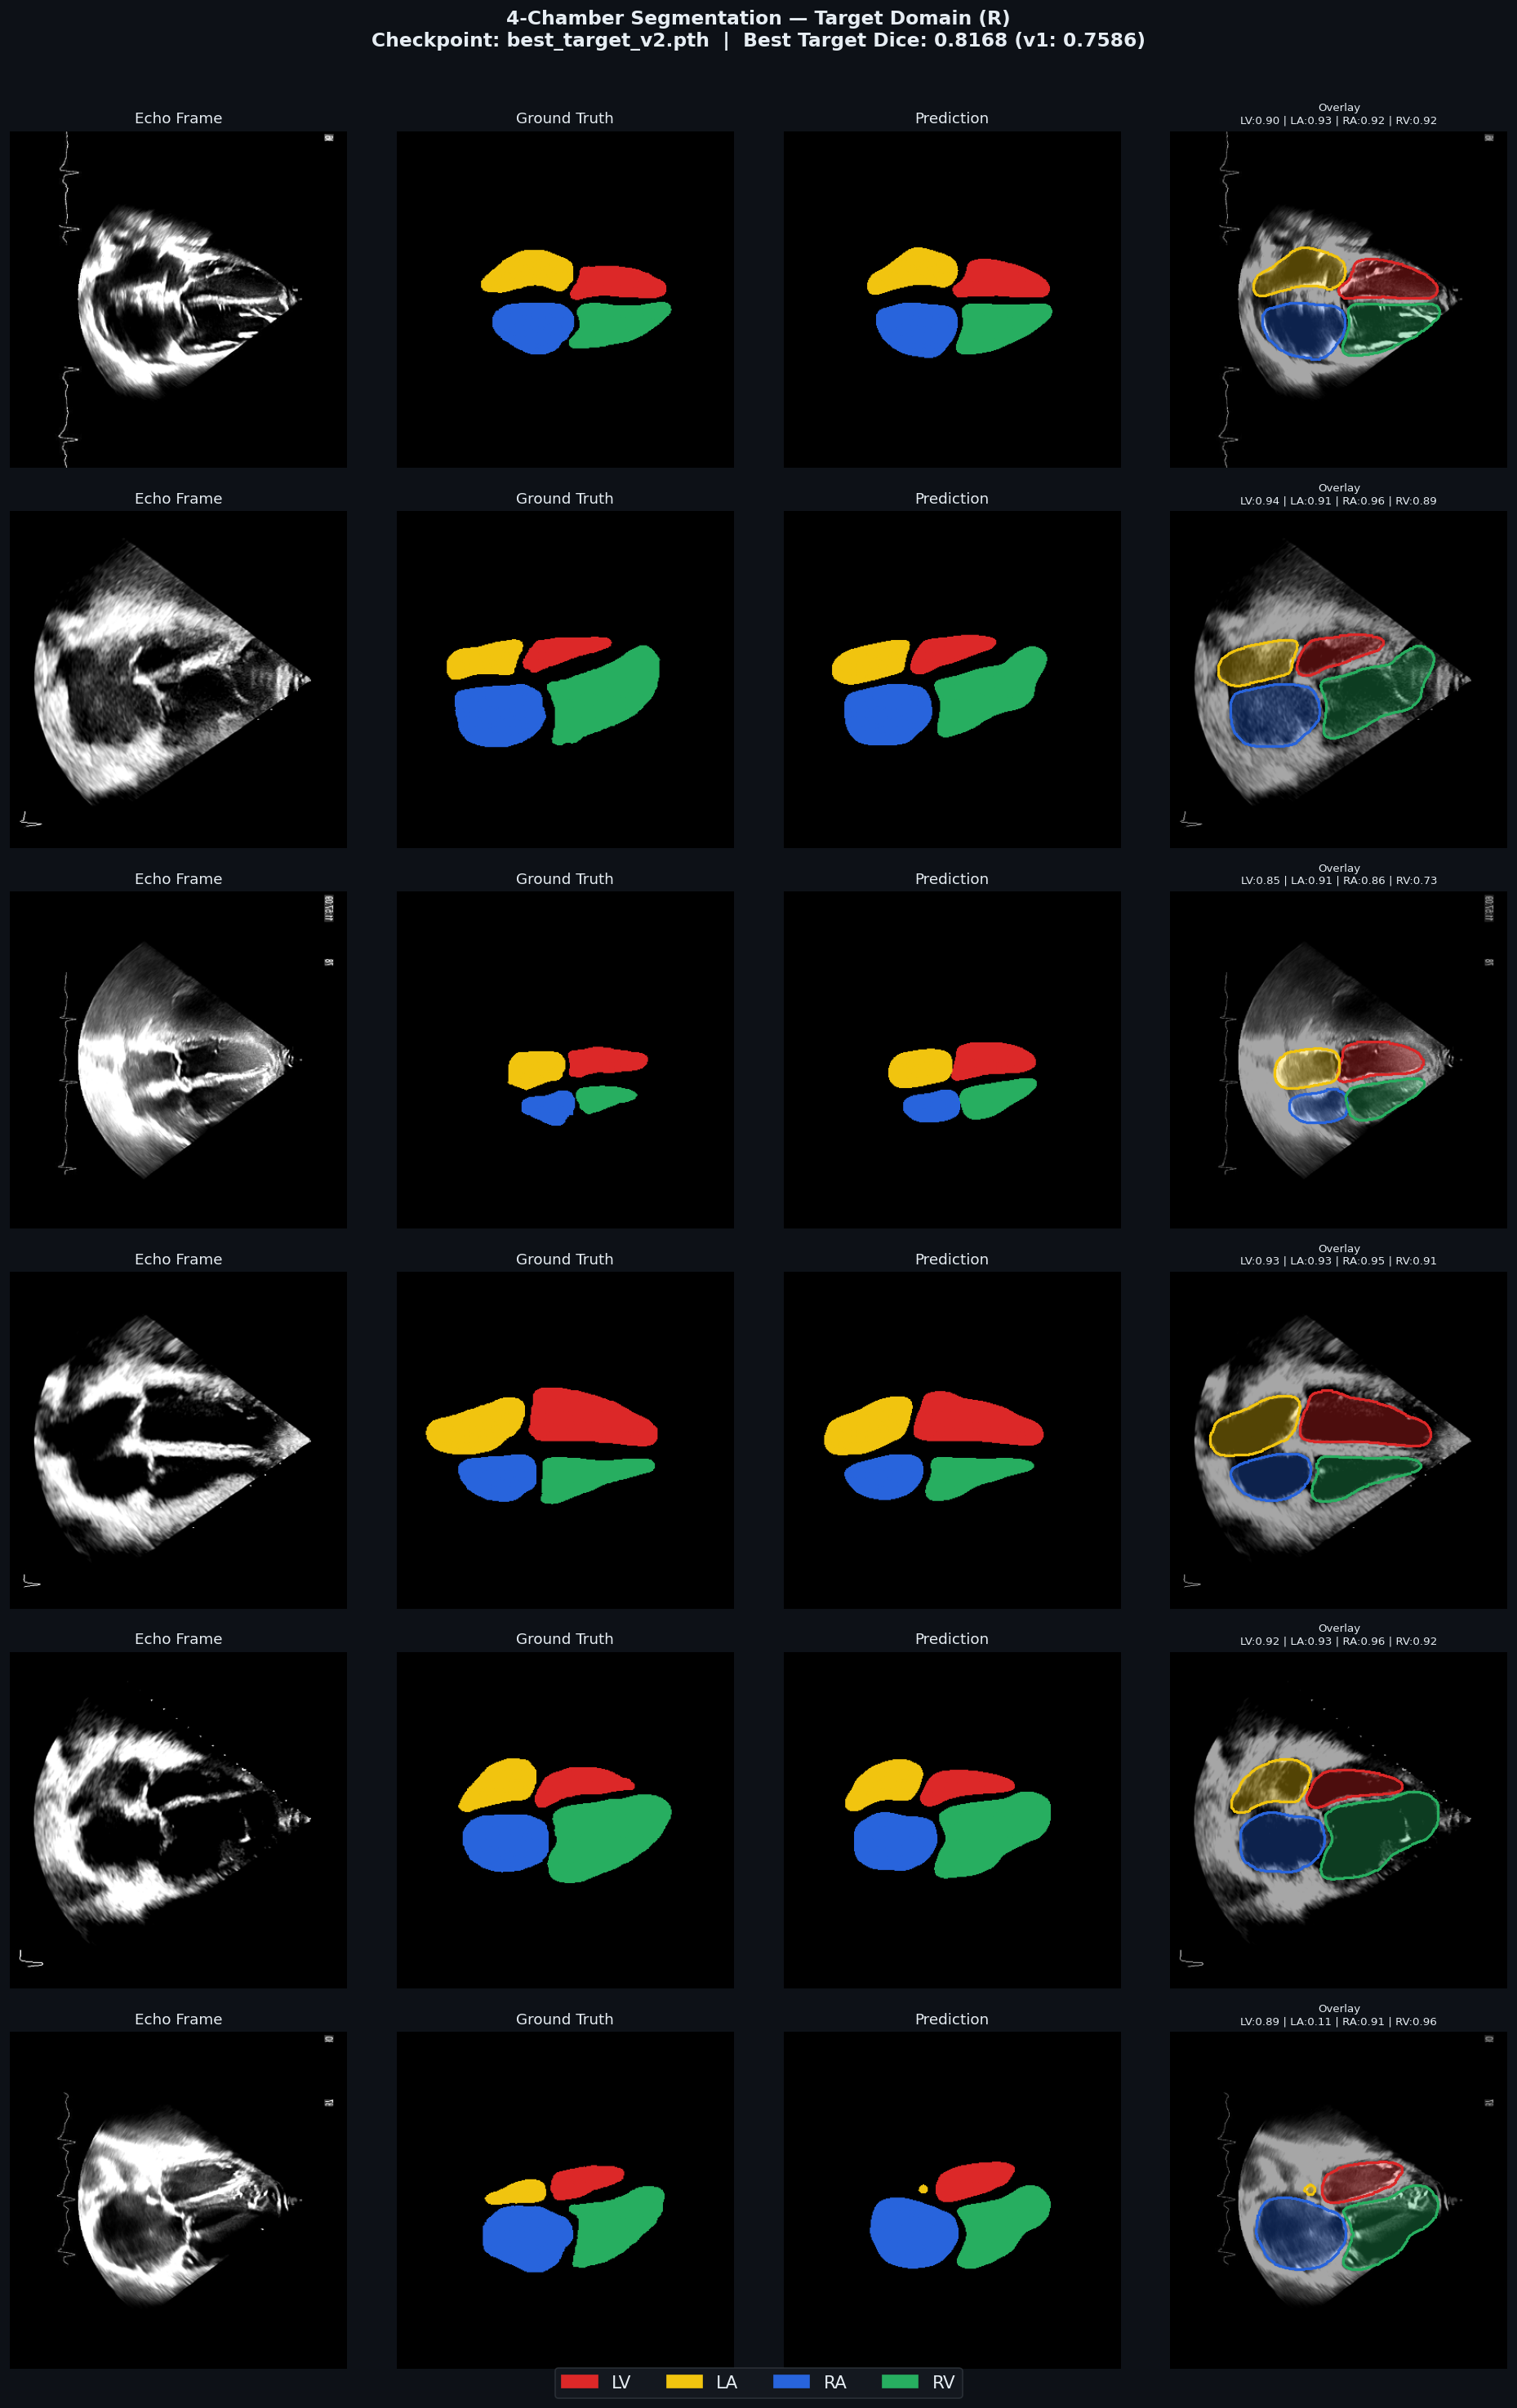

Saved → /scratch/users/joshua04/Echo-Code/checkpoints/segmentation_results_demo.png


In [10]:
# ── Colour map (matches CardiacUDA: 0=BG 1=LV 2=RV 3=LA 4=RA) ─────────────
COLORS = np.array([
    [0,   0,   0  ],   # BG   black
    [220, 40,  40 ],   # LV   red
    [241, 196, 15 ],   # LA   yellow
    [40,  100, 220],   # RA   blue
    [39,  174, 96 ],   # RV   green
], dtype=np.float32) / 255.0
LABELS = ['BG', 'LV', 'LA', 'RA', 'RV']

def mask_to_rgb_uda(mask):
    return COLORS[mask.astype(np.int32)]

def draw_boundaries_uda(ax, mask):
    for c in range(1, 5):
        binary = mask == c
        if not binary.any(): continue
        edge = ndimage.binary_dilation(binary) ^ binary
        y, x = np.where(edge)
        ax.scatter(x, y, s=1, c=[COLORS[c]])

# ── Run inference ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, 4*N_SHOW))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#161b22')
    ax.axis('off')

shown = 0
data_iter = iter(tgt_loader)

with torch.no_grad():
    for imgs, masks in data_iter:
        if shown >= N_SHOW:
            break
        imgs = imgs.to(DEVICE)

        logits = predict_with_tta(seg_model, imgs)
        if isinstance(logits, tuple): logits = logits[0]
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        imgs_np  = imgs.cpu().numpy()
        masks_np = masks.cpu().numpy()

        for i in range(imgs.shape[0]):
            if shown >= N_SHOW:
                break

            img  = imgs_np[i, 0]
            gt   = masks_np[i]
            pred = largest_component(preds[i], num_classes=5)

            img_disp = (img - img.min()) / (img.max() - img.min() + 1e-6)
            gt_rgb   = mask_to_rgb_uda(gt)
            pred_rgb = mask_to_rgb_uda(pred)

            # Dice per class
            dice_strs = []
            for c in range(1, 5):
                inter = ((pred==c) & (gt==c)).sum()
                union = (pred==c).sum() + (gt==c).sum()
                dice_strs.append(
                    f'{LABELS[c]}:{2*inter/union:.2f}' if union > 0 else f'{LABELS[c]}:n/a')
            dice_str = ' | '.join(dice_strs)

            # Col 0: echo
            axes[shown,0].imshow(img_disp, cmap='gray')
            axes[shown,0].set_title('Echo Frame', fontsize=11, color='#e6edf3')

            # Col 1: ground truth
            axes[shown,1].imshow(gt_rgb)
            axes[shown,1].set_title('Ground Truth', fontsize=11, color='#e6edf3')

            # Col 2: prediction
            axes[shown,2].imshow(pred_rgb)
            axes[shown,2].set_title('Prediction', fontsize=11, color='#e6edf3')

            # Col 3: overlay with boundaries
            ax = axes[shown,3]
            ax.imshow(img_disp, cmap='gray')
            overlay = pred_rgb.copy()
            overlay[pred == 0] = 0
            ax.imshow(overlay, alpha=0.35)
            draw_boundaries_uda(ax, pred)
            ax.set_title(f'Overlay\n{dice_str}', fontsize=8, color='#e6edf3')

            shown += 1

# Legend
patches = [mpatches.Patch(color=COLORS[i], label=LABELS[i]) for i in range(1, 5)]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=13, bbox_to_anchor=(0.5, -0.01),
           facecolor='#161b22', labelcolor='#e6edf3', edgecolor='#30363d')

fig.suptitle(
    '4-Chamber Segmentation — Target Domain (R)\n'
    f'Checkpoint: best_target_v2.pth  |  Best Target Dice: 0.8168 (v1: 0.7586)',
    fontsize=14, fontweight='bold', color='#e6edf3', y=1.01)

plt.tight_layout()
save_path = os.path.join(CKPT_DIR, 'segmentation_results_demo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'Saved → {save_path}')

In [32]:
print("Raw grade:", grade_raw.item())
print("Quality logits:", qual_logits)

NameError: name 'grade_raw' is not defined